### Exploratory Data Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("figures", exist_ok=True)
sns.set_style("whitegrid")

In [6]:
df = pd.read_csv("../outputs/cleaned.csv")
print("Loaded shape:", df.shape)
features = [
    "RevolvingUtilization", "Age", "DebtRatio", "MonthlyIncome",
    "OpenCreditLines", "RealEstateLines", "Dependents",
    "Times30_59Late", "Times60_89Late", "Times90Late"
]

Loaded shape: (149233, 11)


### Target Distribution

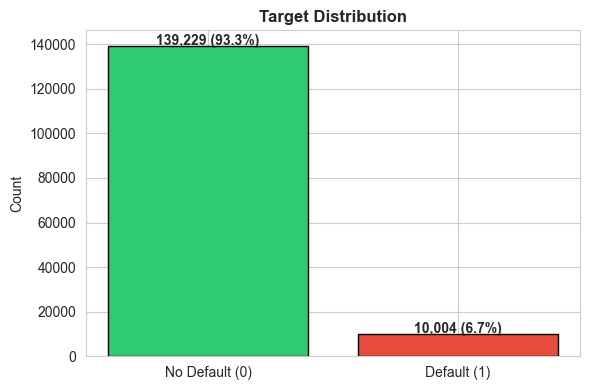

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df["Target"].value_counts().sort_index()
ax.bar(["No Default (0)", "Default (1)"], counts.values, color=["#2ecc71", "#e74c3c"], edgecolor="black")
for i, v in enumerate(counts.values):
    ax.text(i, v + 500, f"{v:,} ({v/len(df)*100:.1f}%)", ha="center", fontweight="bold")
ax.set_title("Target Distribution", fontweight="bold")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("../figures/01_target_distribution.png", dpi=150)
plt.show()

### Feature Histograms

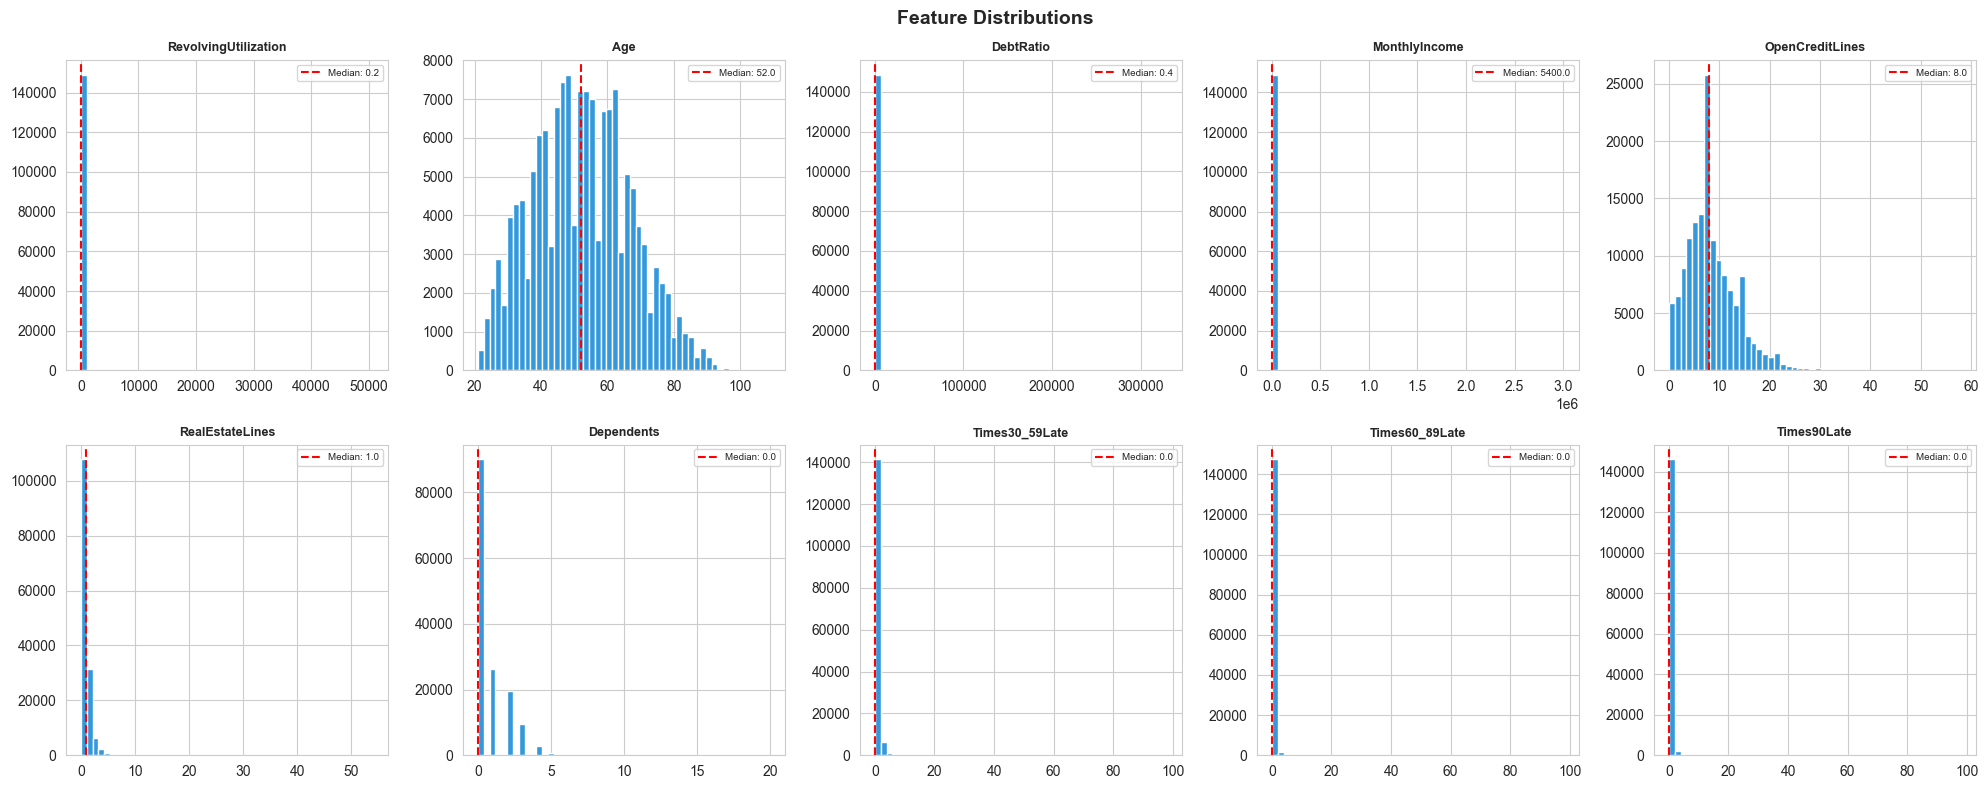

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(features):
    df[col].hist(bins=50, ax=axes[i], color="#3498db", edgecolor="white")
    axes[i].axvline(df[col].median(), color="red", linestyle="--", label=f"Median: {df[col].median():.1f}")
    axes[i].set_title(col, fontsize=9, fontweight="bold")
    axes[i].legend(fontsize=7)
plt.suptitle("Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/02_feature_distributions.png", dpi=150)
plt.show()

### Correlation Heatmap

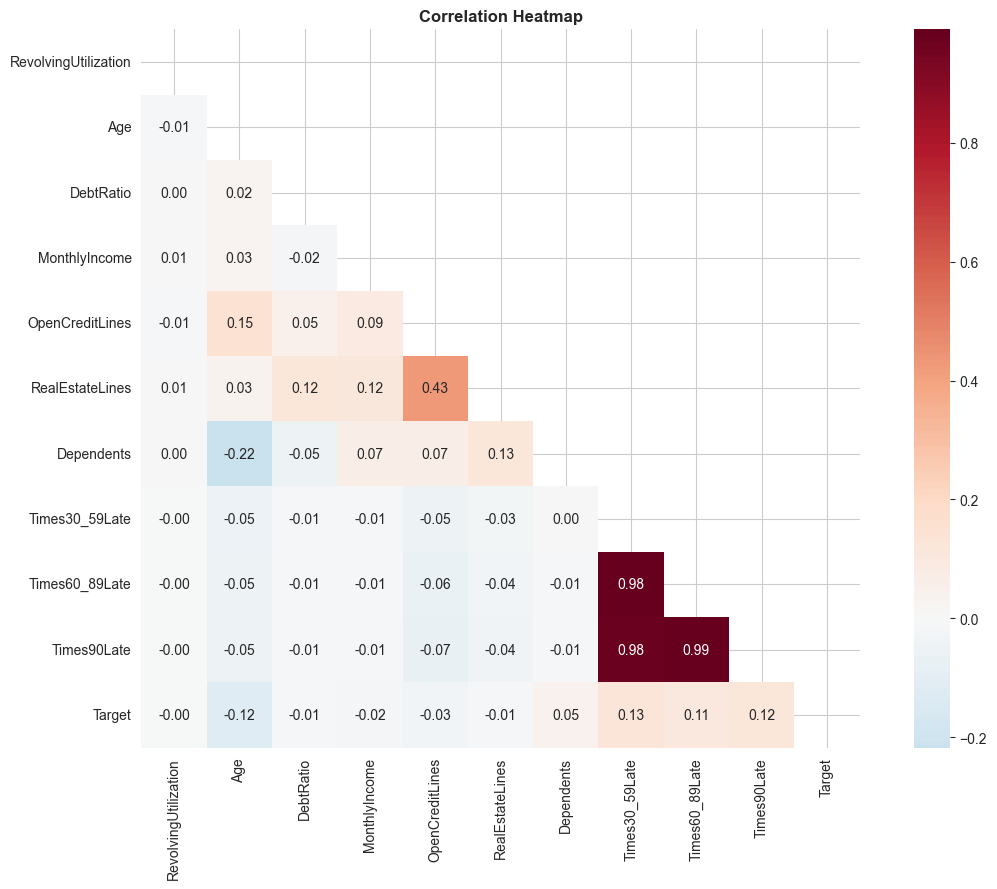

In [10]:
fig, ax = plt.subplots(figsize=(12, 9))
corr = df[features + ["Target"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, ax=ax)
ax.set_title("Correlation Heatmap", fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/03_correlation_heatmap.png", dpi=150)
plt.show()

### Boxplots by Target

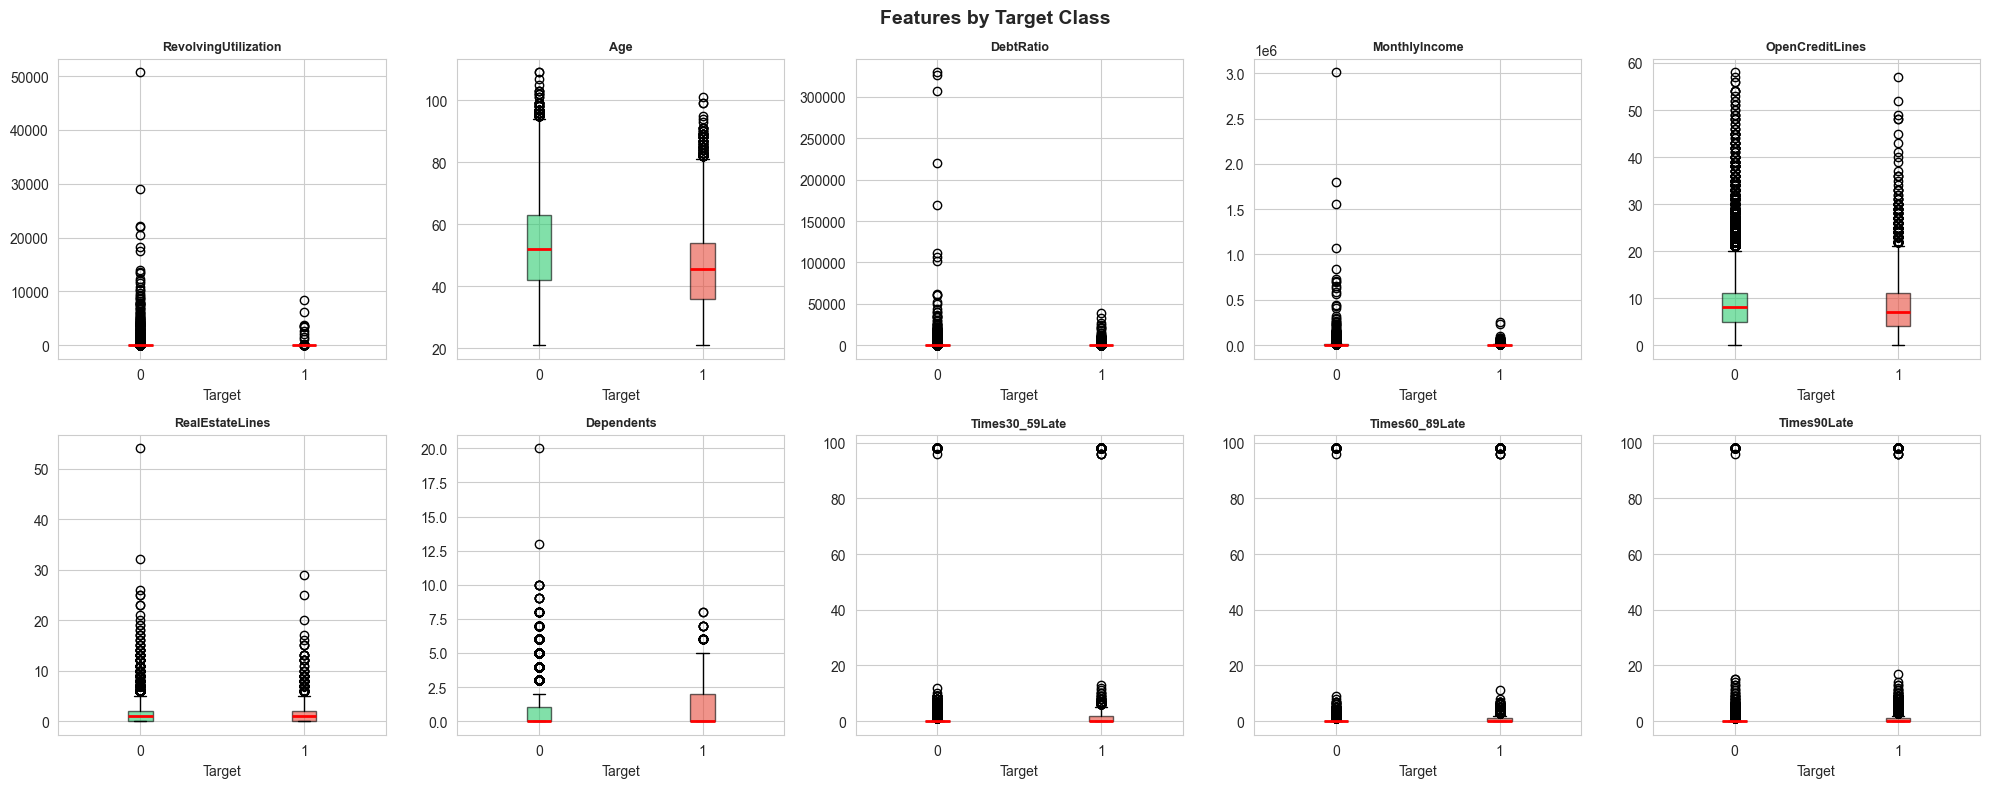

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(features):
    data = [df[df["Target"] == 0][col], df[df["Target"] == 1][col]]
    bp = axes[i].boxplot(data, tick_labels=["0", "1"], patch_artist=True, medianprops=dict(color="red", linewidth=2))
    bp["boxes"][0].set(facecolor="#2ecc71", alpha=0.6)
    bp["boxes"][1].set(facecolor="#e74c3c", alpha=0.6)
    axes[i].set_title(col, fontsize=9, fontweight="bold")
    axes[i].set_xlabel("Target")
plt.suptitle("Features by Target Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/04_boxplots_by_target.png", dpi=150)
plt.show()

### Age Distribution by Target

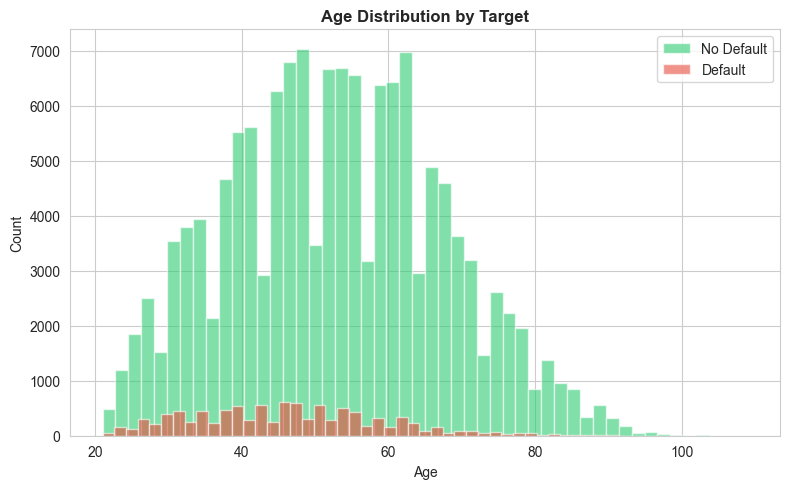

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
df[df["Target"] == 0]["Age"].hist(bins=50, alpha=0.6, color="#2ecc71", label="No Default", ax=ax, edgecolor="white")
df[df["Target"] == 1]["Age"].hist(bins=50, alpha=0.6, color="#e74c3c", label="Default", ax=ax, edgecolor="white")
ax.set_title("Age Distribution by Target", fontweight="bold")
ax.set_xlabel("Age")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/05_age_by_target.png", dpi=150)
plt.show()

### Default Rate by Age Group

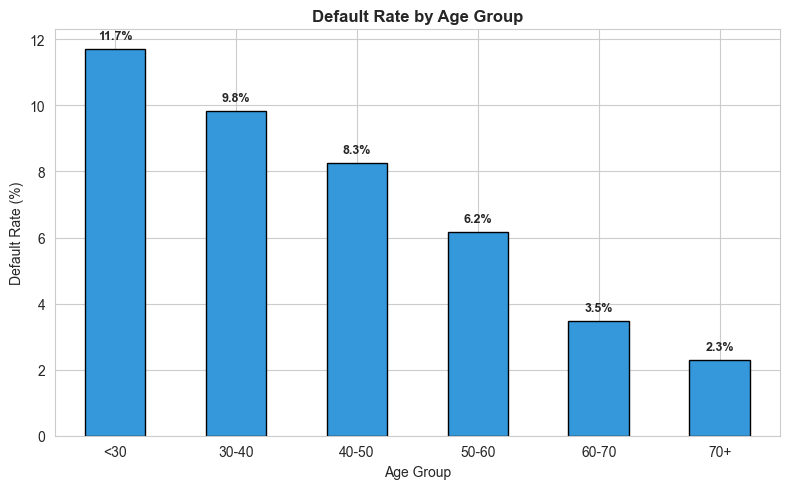

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
df["AgeGroup"] = pd.cut(df["Age"], bins=[0, 30, 40, 50, 60, 70, 120], labels=["<30", "30-40", "40-50", "50-60", "60-70", "70+"])
rate = df.groupby("AgeGroup", observed=True)["Target"].mean() * 100
rate.plot(kind="bar", ax=ax, color="#3498db", edgecolor="black")
for i, v in enumerate(rate.values):
    ax.text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")
ax.set_title("Default Rate by Age Group", fontweight="bold")
ax.set_ylabel("Default Rate (%)")
ax.set_xlabel("Age Group")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../figures/06_default_rate_by_age.png", dpi=150)
plt.show()
df = df.drop(columns=["AgeGroup"])

### Default Rate by Credit Utilization

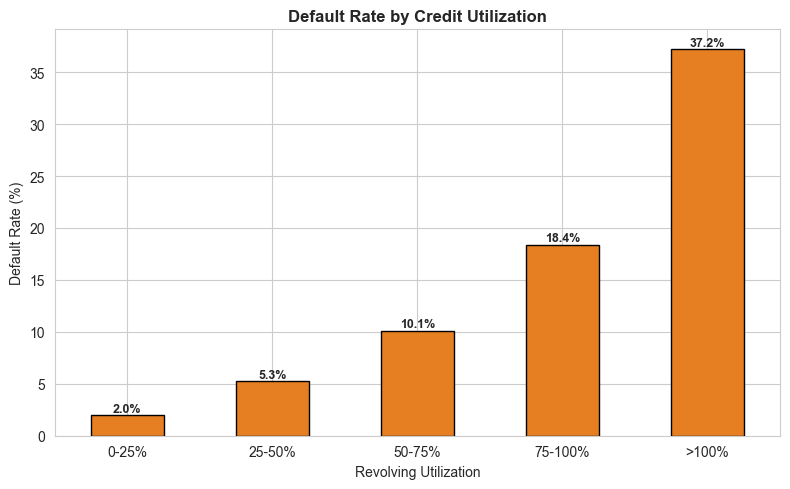

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
df["UtilGroup"] = pd.cut(df["RevolvingUtilization"], bins=[0, 0.25, 0.50, 0.75, 1.0, float("inf")], labels=["0-25%", "25-50%", "50-75%", "75-100%", ">100%"])
rate = df.groupby("UtilGroup", observed=True)["Target"].mean() * 100
rate.plot(kind="bar", ax=ax, color="#e67e22", edgecolor="black")
for i, v in enumerate(rate.values):
    ax.text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")
ax.set_title("Default Rate by Credit Utilization", fontweight="bold")
ax.set_ylabel("Default Rate (%)")
ax.set_xlabel("Revolving Utilization")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../figures/07_default_rate_by_utilization.png", dpi=150)
plt.show()
df = df.drop(columns=["UtilGroup"])

### Summary Statistics

In [15]:
print(df[features].describe().round(2).to_string())

       RevolvingUtilization        Age  DebtRatio  MonthlyIncome  OpenCreditLines  RealEstateLines  Dependents  Times30_59Late  Times60_89Late  Times90Late
count             149233.00  149233.00  149233.00      149233.00        149233.00        149233.00   149233.00       149233.00       149233.00    149233.00
mean                   6.08      52.30     354.81        6426.77             8.49             1.02        0.74            0.39            0.21         0.23
std                  250.40      14.71    2042.89       12922.46             5.13             1.13        1.11            3.78            3.74         3.75
min                    0.00      21.00       0.00           0.00             0.00             0.00        0.00            0.00            0.00         0.00
25%                    0.03      41.00       0.18        3900.00             5.00             0.00        0.00            0.00            0.00         0.00
50%                    0.15      52.00       0.37        5400.00